In [11]:
import numpy as np
from scipy.fft import rfft, irfft, rfftfreq
import matplotlib.pyplot as plt

In [12]:
DOMAIN_SIZE = 100.0
N_DOF = 200
DT = 0.1

# Options: "single", "double", "both"
PRECISION = "both"

In [13]:
class KuramotoSivashinsky():
    def __init__(
        self,
        L,
        N,
        dt,
        float_dtype=np.float64,
    ):
        self.L = L
        self.N = N
        self.dt = dt
        self.dx = L / N
        self.float_dtype = float_dtype
        self.complex_dtype = np.complex64 if float_dtype == np.float32 else np.complex128

        wavenumbers = rfftfreq(N, d=L / (N * 2 * np.pi)).astype(self.float_dtype)
        self.derivative_operator = (1j * wavenumbers).astype(self.complex_dtype)

        linear_operator = (- self.derivative_operator**2 - self.derivative_operator**4)
        self.exp_term = np.exp(dt * linear_operator)
        self.coef = np.where(
            linear_operator == 0.0,
            dt,
            (self.exp_term - 1.0) / linear_operator,
        )

        self.alias_mask = (wavenumbers < 2/3 * np.max(wavenumbers)).astype(self.float_dtype)

    def __call__(
        self,
        u,
    ):
        u_nonlin = -0.5 * u**2
        u_hat = rfft(u)
        u_nonlin_hat = rfft(u_nonlin)
        u_nonlin_hat = self.alias_mask * u_nonlin_hat
        u_nonlin_der_hat = self.derivative_operator * u_nonlin_hat

        u_next_hat = self.exp_term * u_hat + self.coef * u_nonlin_der_hat
        u_next = irfft(u_next_hat, n=self.N)
        return u_next.astype(self.float_dtype)

In [14]:
mesh = np.linspace(0.0, DOMAIN_SIZE, N_DOF, endpoint=False)

# Determine which precisions to run
if PRECISION == "both":
    precisions = {"single": np.float32, "double": np.float64}
elif PRECISION == "single":
    precisions = {"single": np.float32}
else:
    precisions = {"double": np.float64}

In [15]:
u_0_base = np.sin(16 * np.pi * mesh / DOMAIN_SIZE)

In [16]:
# Build steppers and initial conditions for each precision
steppers = {}
u_0s = {}
for label, dtype in precisions.items():
    steppers[label] = KuramotoSivashinsky(L=DOMAIN_SIZE, N=N_DOF, dt=DT, float_dtype=dtype)
    u_0s[label] = u_0_base.astype(dtype)
    print(f"  {label}: float_dtype={dtype.__name__}")

  single: float_dtype=float32
  double: float_dtype=float64


/tmp/ipykernel_12808/2108241755.py:24: RuntimeWarning: invalid value encountered in divide
  (self.exp_term - 1.0) / linear_operator,


Text(0.5, 1.0, 'Initial steps by precision')

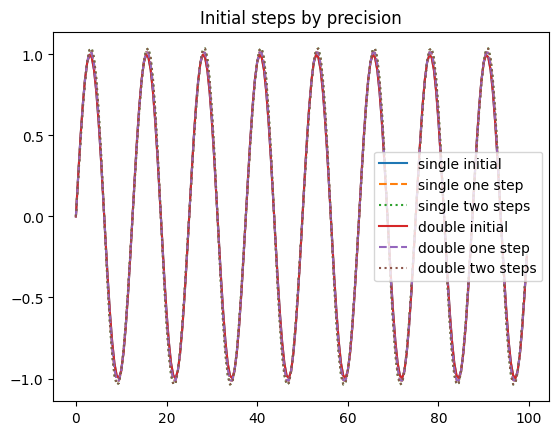

In [17]:
for label in precisions:
    stepper = steppers[label]
    u0 = u_0s[label]
    plt.plot(mesh, u0, label=f"{label} initial")
    plt.plot(mesh, stepper(u0), label=f"{label} one step", linestyle="--")
    plt.plot(mesh, stepper(stepper(u0)), label=f"{label} two steps", linestyle=":")
plt.legend()
plt.title("Initial steps by precision")

In [18]:
# Autoregressively producing a rollout -> trajectory for each precision
N_STEPS = 2000
trajectories = {}
for label in precisions:
    stepper = steppers[label]
    u_current = u_0s[label].copy()
    trj = [u_current]
    for i in range(N_STEPS):
        u_current = stepper(u_current)
        trj.append(u_current)
    trajectories[label] = np.stack(trj)
    print(f"  {label}: trajectory shape={trajectories[label].shape}, dtype={trajectories[label].dtype}")

  single: trajectory shape=(2001, 200), dtype=float32
  double: trajectory shape=(2001, 200), dtype=float64


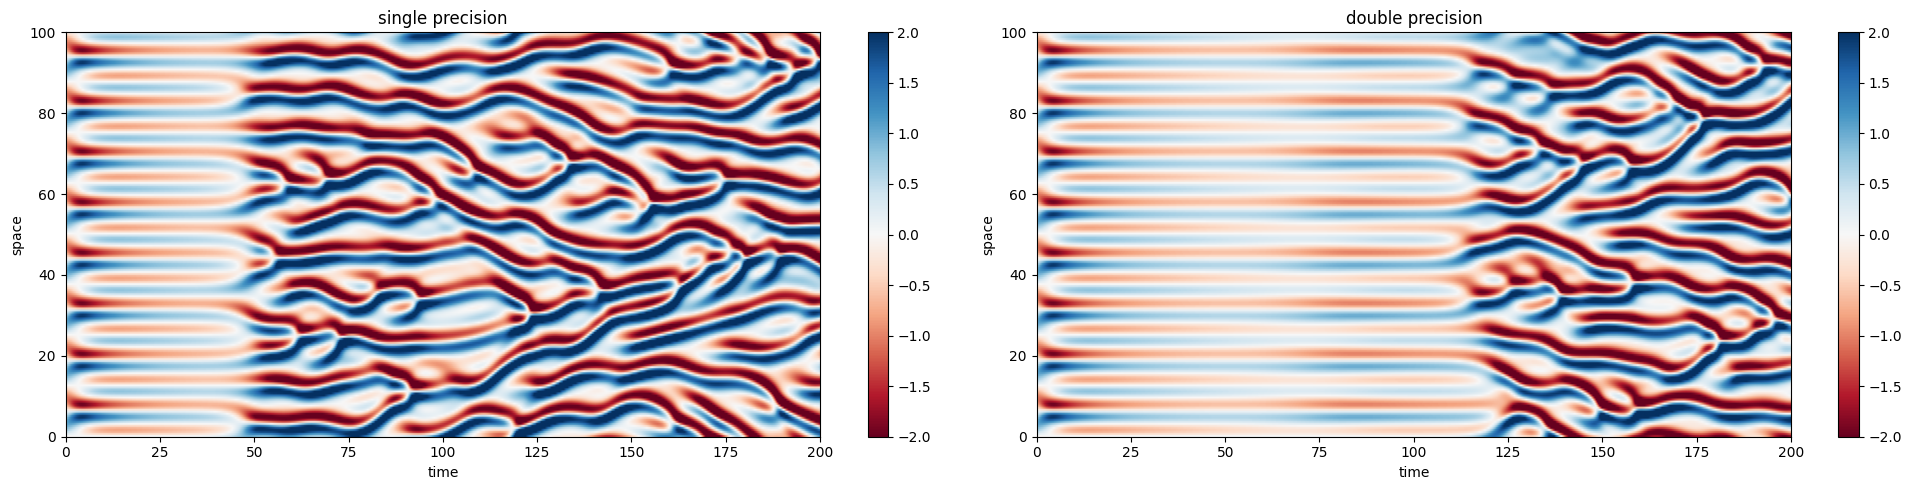

In [19]:
fig, axes = plt.subplots(1, len(precisions), figsize=(10 * len(precisions), 5), squeeze=False)
for ax, label in zip(axes[0], precisions):
    trj = trajectories[label]
    im = ax.imshow(
        trj.T,
        cmap="RdBu",
        aspect="auto",
        origin="lower",
        extent=(0, trj.shape[0] * DT, 0, DOMAIN_SIZE),
        vmin=-2,
        vmax=2,
    )
    ax.set_title(f"{label} precision")
    ax.set_xlabel("time")
    ax.set_ylabel("space")
    fig.colorbar(im, ax=ax)
plt.tight_layout()

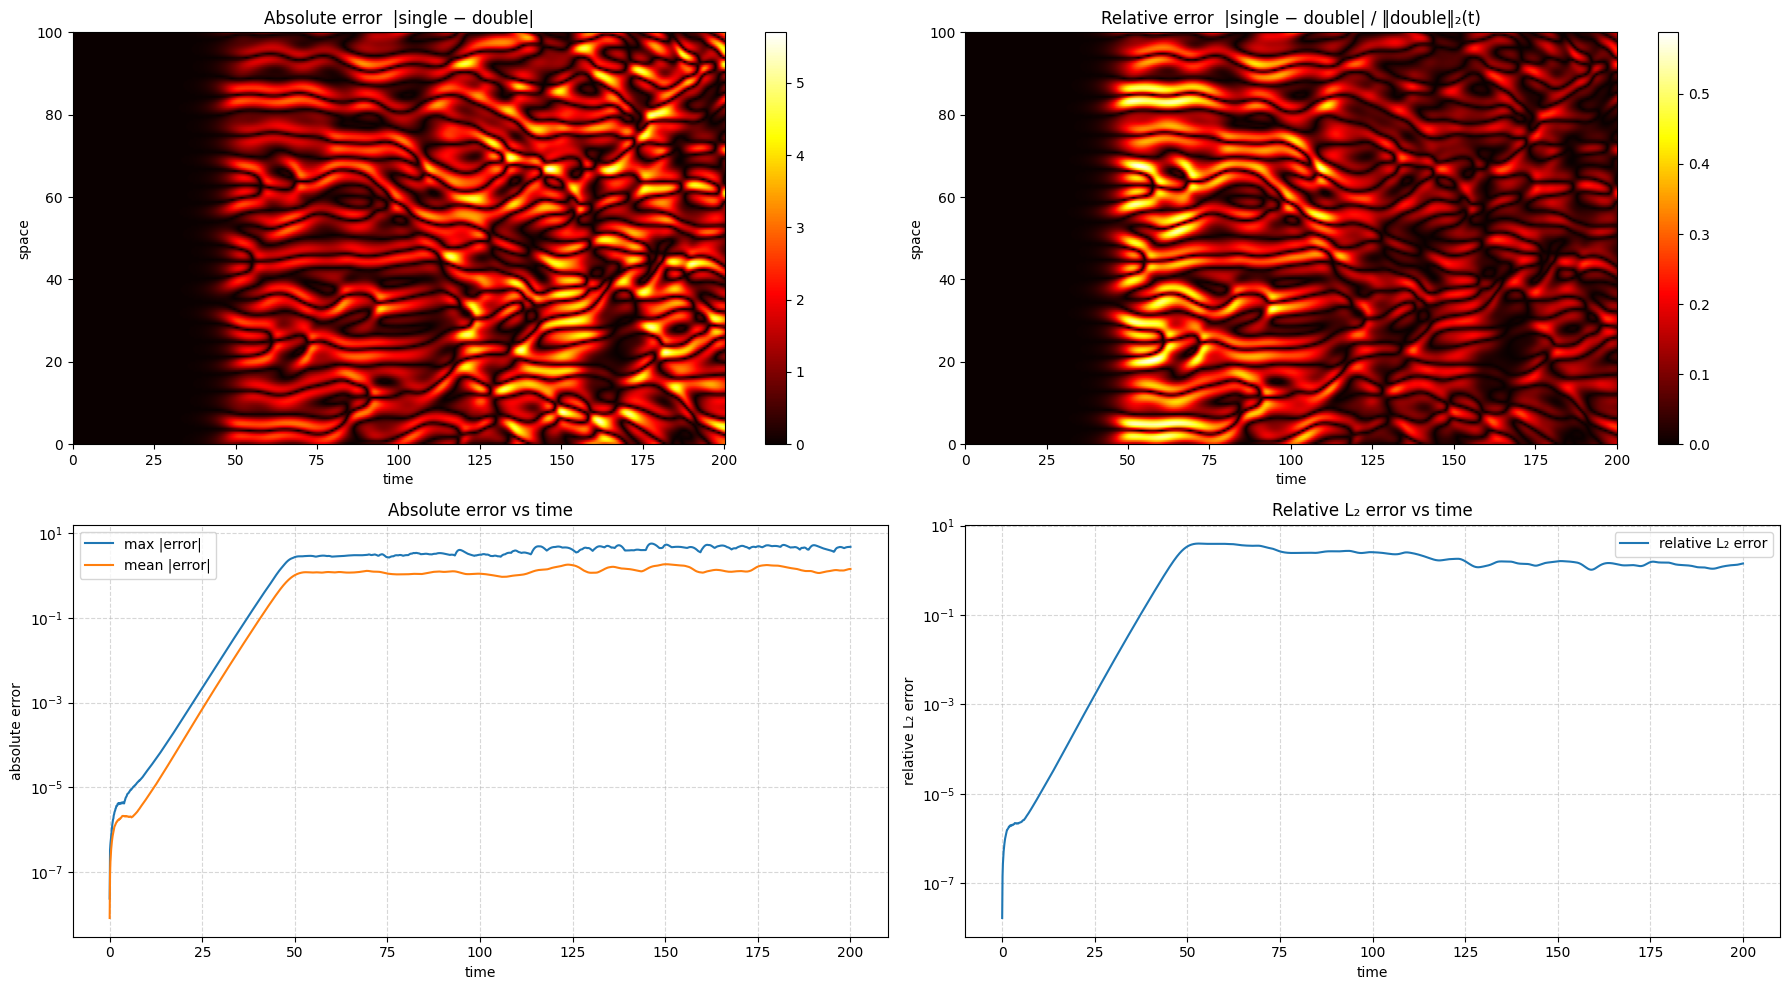

In [20]:
if PRECISION == "both":
    trj_single = trajectories["single"].astype(np.float64)
    trj_double = trajectories["double"]
    error = np.abs(trj_single - trj_double)
    time_axis = np.arange(trj_double.shape[0]) * DT

    # Per-timestep norms for meaningful relative error (avoids zero-crossing blowup)
    norm_per_step = np.linalg.norm(trj_double, axis=1, keepdims=True)  # (T, 1)
    rel_error = error / np.clip(norm_per_step, a_min=1e-10, a_max=None)

    fig, axes = plt.subplots(2, 2, figsize=(18, 10))

    # --- Top-left: absolute error heatmap ---
    im0 = axes[0, 0].imshow(
        error.T,
        cmap="hot",
        aspect="auto",
        origin="lower",
        extent=(0, trj_double.shape[0] * DT, 0, DOMAIN_SIZE),
    )
    axes[0, 0].set_title("Absolute error  |single − double|")
    axes[0, 0].set_xlabel("time")
    axes[0, 0].set_ylabel("space")
    fig.colorbar(im0, ax=axes[0, 0])

    # --- Top-right: relative error heatmap (normalized by per-step L2 norm) ---
    im1 = axes[0, 1].imshow(
        rel_error.T,
        cmap="hot",
        aspect="auto",
        origin="lower",
        extent=(0, trj_double.shape[0] * DT, 0, DOMAIN_SIZE),
    )
    axes[0, 1].set_title("Relative error  |single − double| / ‖double‖₂(t)")
    axes[0, 1].set_xlabel("time")
    axes[0, 1].set_ylabel("space")
    fig.colorbar(im1, ax=axes[0, 1])

    # --- Bottom-left: max & mean abs error vs time ---
    max_err = error.max(axis=1)
    mean_err = error.mean(axis=1)
    axes[1, 0].semilogy(time_axis, max_err, label="max |error|")
    axes[1, 0].semilogy(time_axis, mean_err, label="mean |error|")
    axes[1, 0].set_xlabel("time")
    axes[1, 0].set_ylabel("absolute error")
    axes[1, 0].set_title("Absolute error vs time")
    axes[1, 0].legend()
    axes[1, 0].grid(True, which="both", ls="--", alpha=0.5)

    # --- Bottom-right: relative L2 error vs time ---
    rel_l2 = np.linalg.norm(error, axis=1) / np.clip(norm_per_step.squeeze(), a_min=1e-10, a_max=None)
    axes[1, 1].semilogy(time_axis, rel_l2, label="relative L₂ error")
    axes[1, 1].set_xlabel("time")
    axes[1, 1].set_ylabel("relative L₂ error")
    axes[1, 1].set_title("Relative L₂ error vs time")
    axes[1, 1].legend()
    axes[1, 1].grid(True, which="both", ls="--", alpha=0.5)

    plt.tight_layout()
else:
    print("Set PRECISION = 'both' to see single vs double comparison plots.")